<div style="background:linear-gradient(135deg,#136a8a 0%,#267871 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🧩&nbsp; The Composable API: Problem, Trainer, Strategy</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">The previous notebooks wrote a residual by hand and drove a training loop themselves. That is the right way to learn, and the wrong way to run an experiment: the equation and the optimisation get tangled together, so changing one means editing the other. This notebook takes the same physics and splits it in two — a <i>problem</i> that knows the equation, and a <i>trainer</i> that knows nothing about it. Then it shows what that split buys you.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#e08600;color:#fff;padding:4px 8px;">intermediate</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">composable core</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">PDE</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">Allen–Cahn (reaction–diffusion)</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~7 min CPU</span></span></div>

Two notebooks in this gallery build a PINN the explicit way. [Allen–Cahn](02_allen_cahn.ipynb)
writes the residual with raw `torch.autograd.grad` calls, and [Bring Your Own PDE](03_custom_pde.ipynb)
hand-rolls the training loop around it. Both are worth reading first, because everything here is built
on what they do by hand.

The cost of that style shows up the moment you want to *change* something. The sampling strategy, the
optimiser schedule, the loss weighting and the equation all live in the same loop, so swapping one means
editing code that the others depend on. Comparing two strategies means maintaining two copies of the loop
and hoping they differ only where you intended.

`pinnlab` splits that into three objects:

| object | knows | does not know |
|---|---|---|
| `AllenCahnProblem` | the equation, its geometry, its constraints | how it will be optimised |
| `TrainerConfig` | budget, sampling, precision, strategies | which PDE is being solved |
| `Trainer` | how to combine residual and constraint losses | either of the above specifically |

The payoff is concrete and this notebook measures it: Allen–Cahn has a failure mode that plain training
walks straight into, and fixing it is a one-field change to the config with the problem untouched.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#anatomy" style="color:#1a73e8;text-decoration:none;">2 · Anatomy of a Problem</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">3 · Training It</a></li>
  <li style="margin:3px 0;"><a href="#trap" style="color:#1a73e8;text-decoration:none;">4 · The Trivial Solution</a></li>
  <li style="margin:3px 0;"><a href="#swap" style="color:#1a73e8;text-decoration:none;">5 · Swapping a Strategy</a></li>
  <li style="margin:3px 0;"><a href="#score" style="color:#1a73e8;text-decoration:none;">6 · Scoring Against a Reference</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">7 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>
## 1 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="anatomy"></a>
## 2 · Anatomy of a Problem

A problem is a plain object. It answers four questions — what shape are my inputs, where do I live,
what is my residual, and what must be true on the boundary — and nothing else. Note what is *absent*:
no optimiser, no learning rate, no sampling.

In [2]:
from pinnlab.problems import AllenCahnProblem, AllenCahnConfig

problem = AllenCahnProblem(config=AllenCahnConfig(nu=1e-2), n_constraint_samples=200)

print(f"equation      : u_t - nu*u_xx + gamma*(u^3 - u) = 0")
print(f"nu, gamma     : {problem.config.nu}, {problem.config.gamma}")
print(f"input_dim     : {problem.input_dim}   (t, x)")
print(f"output_dim    : {problem.output_dim}")
print(f"geometry      : {type(problem.geometry).__name__} "
      f"t∈[{problem.geometry.lower_bounds[0]:.0f},{problem.geometry.upper_bounds[0]:.0f}] "
      f"x∈[{problem.geometry.lower_bounds[1]:.0f},{problem.geometry.upper_bounds[1]:.0f}]")
print(f"reference_kind: {problem.reference_kind}")
print()
print("constraints:")
for c in problem.constraints():
    extra = f", derivative_order={c.derivative_order}" if hasattr(c, "derivative_order") else ""
    print(f"  • {c.name:18s} {type(c).__name__}{extra}")

equation      : u_t - nu*u_xx + gamma*(u^3 - u) = 0
nu, gamma     : 0.01, 5.0
input_dim     : 2   (t, x)
output_dim    : 1
geometry      : Rectangle t∈[0,1] x∈[-1,1]
reference_kind: numerical

constraints:
  • ic                 InitialCondition
  • bc_periodic        PeriodicBoundary, derivative_order=0
  • bc_periodic_flux   PeriodicBoundary, derivative_order=1


<div style="background:#eaf2ff;border-left:5px solid #1a73e8;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>🧭 Why two periodic constraints?</b> Matching <i>values</i> across the seam is not periodicity — it
  permits a field with a kink at <code>x = ±1</code>, and the residual never objects because no collocation
  point straddles the far face. The second constraint matches <code>u_x</code> as well. The test that pins this
  down uses <code>u = x²</code>: it matches by value at both ends while its slope there is <code>-2</code> and
  <code>+2</code>.
</div>

<a id="train"></a>
## 3 · Training It

The trainer takes the problem and a config. Everything about *how* to train lives in `TrainerConfig`;
nothing in it mentions Allen–Cahn. The same config would train the heat equation.

In [3]:
from pinnlab.models import MLP
from pinnlab.training import Trainer, TrainerConfig, OptimizerConfig

def make_config(causal=None):
    """Budget held identical across every run in this notebook."""
    return TrainerConfig(
        seed=SEED,
        collocation_count=2000,
        optimizer=OptimizerConfig(lr=1e-3, adam_steps=1500, lbfgs_max_iter=200),
        loss_weights={"ic": 100.0, "bc_periodic": 100.0, "bc_periodic_flux": 100.0},
        log_every=500,
        causal=causal,
    )

def train(causal=None):
    torch.manual_seed(SEED)
    model = MLP(in_dim=2, hidden_layers=4, width=64, out_dim=1)
    result = Trainer(make_config(causal)).train(problem, model)
    return model, result

model_plain, result_plain = train()

final = result_plain.final_state
print("final losses")
for name, value in final.named_losses.items():
    print(f"  {name:20s} {value:.3e}")

final losses
  pde                  8.902e-01
  ic                   6.989e-04
  bc_periodic          2.322e-05
  bc_periodic_flux     1.117e-05


<a id="trap"></a>
## 4 · The Trivial Solution

Those losses look healthy. Three of the four are tiny. Now look at the solution itself.

Allen–Cahn has a trap that is worth understanding before trusting any run of it: **`u = 0` satisfies the
PDE exactly**. It is the unstable equilibrium sitting between the two phases, and it satisfies both
periodic constraints exactly too. The only term that objects is the initial condition, and only on the
`t = 0` face.

So there is a wide, easily reached basin where the network fits the initial condition, decays to zero
immediately after, and reports three loss components at their minimum while being useless.

In [4]:
xs = torch.linspace(-1, 1, 9)

def profile(model, t):
    with torch.no_grad():
        return model(torch.stack([torch.full((9,), t), xs], 1)).numpy().ravel()

print("u(t, x) across the domain\n")
print("      x =" + "".join(f"{v:7.2f}" for v in xs.numpy()))
for t in (0.0, 0.25, 0.5, 1.0):
    print(f"t={t:<5.2f} " + "".join(f"{v:7.2f}" for v in profile(model_plain, t)))

grid = problem.reference_grid(n_t=41, n_x=512, steps_per_snapshot=100)
coords = torch.tensor(np.stack([grid["t"].ravel(), grid["x"].ravel()], 1), dtype=torch.float32)
with torch.no_grad():
    pred_plain = model_plain(coords).numpy().reshape(grid["t"].shape)

print(f"\nmean |u|  predicted {np.abs(pred_plain).mean():.3f}   "
      f"reference {np.abs(grid['reference']).mean():.3f}")

u(t, x) across the domain

      x =  -1.00  -0.75  -0.50  -0.25   0.00   0.25   0.50   0.75   1.00
t=0.00    -0.95  -0.38   0.01   0.03   0.02   0.03   0.01  -0.38  -0.95
t=0.25    -0.40  -0.16   0.04   0.02   0.02   0.02   0.01  -0.08  -0.39
t=0.50    -0.14  -0.04   0.04  -0.01  -0.01   0.01  -0.01  -0.03  -0.14
t=1.00    -0.02  -0.01   0.10   0.02  -0.04   0.00   0.02   0.01   0.00



mean |u|  predicted 0.061   reference 0.578


<a id="swap"></a>
## 5 · Swapping a Strategy

The collapse above is a *causality* failure: nothing forces the network to respect that early times
determine late ones, so it is free to satisfy the equation in the cheapest way available.

Causal weighting fixes exactly this. It splits the time axis into chunks and refuses to credit a chunk's
residual until the chunks before it are already small, so the solution has to grow forward from the
initial condition instead of collapsing everywhere at once.

**This is the part worth noticing.** The problem object does not change. The model does not change. The
budget does not change. One field of the config changes.

In [5]:
from pinnlab.training.causal_weighting import CausalWeightConfig

model_causal, result_causal = train(
    causal=CausalWeightConfig(enabled=True, n_chunks=16, eps=1.0)
)

with torch.no_grad():
    pred_causal = model_causal(coords).numpy().reshape(grid["t"].shape)

def rel_l2(pred):
    return np.linalg.norm(pred - grid["reference"]) / np.linalg.norm(grid["reference"])

print(f"{'':22s}{'rel L2':>10s}{'mean |u|':>12s}")
print(f"{'unweighted':22s}{rel_l2(pred_plain):10.3f}{np.abs(pred_plain).mean():12.3f}")
print(f"{'causal (eps=1, 16)':22s}{rel_l2(pred_causal):10.3f}{np.abs(pred_causal).mean():12.3f}")
print(f"{'reference':22s}{'--':>10s}{np.abs(grid['reference']).mean():12.3f}")

                          rel L2    mean |u|
unweighted                 0.940       0.061
causal (eps=1, 16)         0.791       0.477
reference                     --       0.578


<div style="background:#fdeef2;border-left:5px solid #d6336c;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>⚠️ One run is not a measurement.</b> The cells above are a single seed, shown so you can watch the
  mechanism rather than take it on faith. Run-to-run spread on these problems is 2.2–2.6×, which is wider
  than most differences worth arguing about.<br><br>
  The claim this notebook actually rests on was measured over <b>four seeds per configuration at this
  same budget</b>, one of which is the run printed above: median relative L2 of <b>0.920</b> unweighted
  (range 0.913–0.940) against <b>0.651</b> weighted (range 0.600–0.791). The ranges are disjoint —
  the worst weighted run still beats the best unweighted one — which is the bar a comparison has to clear
  here. Mean <code>|u|</code> rose from 0.06–0.08 to 0.32–0.48 against a reference of 0.578, so the
  mechanism is visible directly and not only in the score.<br><br>
  Note how wide those bands are, and that the run above sits at the unlucky end of both. That is the
  point of quoting a range: a single number from this notebook could have been 0.60 or 0.79 depending on
  nothing but the seed.<br><br>
  Read that as “causal weighting works, and this is where it bites” — <i>not</i> as “Allen–Cahn is solved”.
  At 0.6 relative error the weighted runs are still far from accurate; the budget here is small and the
  architecture untuned.
</div>

<a id="score"></a>
## 6 · Scoring Against a Reference

Allen–Cahn has no closed-form solution, so there is nothing to compare against analytically. `pinnlab`
ships a *numerical* reference instead — Fourier spectral in space, integrating-factor RK4 in time — and
labels it as such. That is why the method is called `reference_grid` and not `exact`, and why
`problem.reference_kind` reports `"numerical"`.

It is verified against the two limits where the answer *is* known: with `gamma = 0` it reproduces the heat
equation to 1.8e-15, with `nu = 0` the logistic ODE to 5e-11, and halving the step divides its error by
16.2, as fourth order requires.

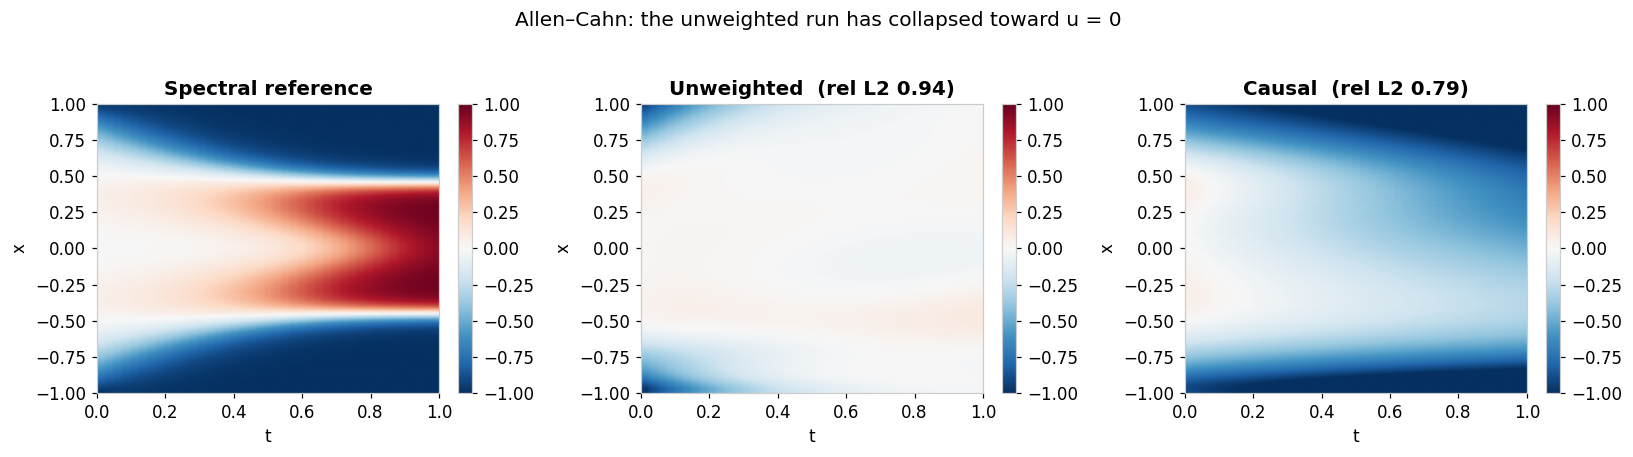

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    (grid["reference"], "Spectral reference", "RdBu_r"),
    (pred_plain,        f"Unweighted  (rel L2 {rel_l2(pred_plain):.2f})",  "RdBu_r"),
    (pred_causal,       f"Causal  (rel L2 {rel_l2(pred_causal):.2f})",     "RdBu_r"),
]
for ax, (data, title, cmap) in zip(axes, panels):
    im = ax.imshow(data.T, origin="lower", aspect="auto", cmap=cmap, vmin=-1, vmax=1,
                   extent=[0, 1, -1, 1])
    ax.set_title(title); ax.set_xlabel("t"); ax.set_ylabel("x"); ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Allen–Cahn: the unweighted run has collapsed toward u = 0", y=1.03)
plt.tight_layout(); plt.show()

<a id="takeaways"></a>
## 7 · Takeaways

- A **problem** owns the equation, its geometry and its constraints. A **`TrainerConfig`** owns the budget
  and the strategies. Neither mentions the other, which is what made the comparison above a one-field
  change rather than a second training loop.
- Because the split holds, every strategy the trainer supports — causal weighting here, but equally
  residual-adaptive refinement, Latin hypercube sampling or nondimensionalisation — works on any problem
  without the problem knowing they exist.
- **Healthy-looking losses are not a healthy solution.** The unweighted run reported three of four
  components at their minimum while sitting on the trivial solution. Score against a reference, and look
  at the field.
- References carry provenance. `reference_kind` distinguishes an analytic solution from a numerical one,
  so a benchmark cannot quietly claim more authority than it has.
- Quote medians over seeds with ranges attached, not single runs. On these problems a single run cannot
  resolve a 2× difference.

### Where next

- [Allen–Cahn from scratch](02_allen_cahn.ipynb) — the same physics with a hand-written residual, which is
  what the problem object is wrapping.
- [Bring Your Own PDE](03_custom_pde.ipynb) — the hand-rolled training loop this notebook replaces.
- [Heat equation](05_heat_equation.ipynb) — a problem with a closed-form solution, so `reference_kind` is
  `"analytic"` there.

### 📚 References

1. Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks.*
   **Journal of Computational Physics**, 378, 686–707.
2. Wang, S., Sankaran, S., & Perdikaris, P. (2022). *Respecting causality is all you need for training
   physics-informed neural networks.* [arXiv:2203.07404](https://arxiv.org/abs/2203.07404)
3. Allen, S. M., & Cahn, J. W. (1979). *A microscopic theory for antiphase boundary motion.*
   **Acta Metallurgica**, 27(6), 1085–1095.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>